In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()
model = ChatOpenAI()

In [3]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [4]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [5]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [6]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()


In [7]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': 'I. Introduction\n    A. Definition of AI\n    B. Significance of AI in India\n    C. Overview of the rise of AI in India\n\nII. History of AI in India\n    A. Early developments in AI in India\n    B. Government initiatives to promote AI\n    C. Role of Indian startups in AI development\n\nIII. Current state of AI in India\n    A. AI adoption in various sectors \n    B. Challenges faced by AI in India\n    C. Success stories of AI implementation in India\n\nIV. Future of AI in India\n    A. Growth projections for AI in India\n    B. Potential impact of AI on the Indian economy\n    C. Opportunities and challenges for AI in India\n\nV. Ethical considerations of AI in India\n    A. Privacy concerns surrounding AI in India\n    B. Bias in AI algorithms in the Indian context\n    C. Regulations and policies governing AI in India\n\nVI. Case studies of AI implementation in India\n    A. Healthcare\n    B. Agriculture\n    C. Finance\n    D. Manuf

In [8]:
print(final_state['outline'])

I. Introduction
    A. Definition of AI
    B. Significance of AI in India
    C. Overview of the rise of AI in India

II. History of AI in India
    A. Early developments in AI in India
    B. Government initiatives to promote AI
    C. Role of Indian startups in AI development

III. Current state of AI in India
    A. AI adoption in various sectors 
    B. Challenges faced by AI in India
    C. Success stories of AI implementation in India

IV. Future of AI in India
    A. Growth projections for AI in India
    B. Potential impact of AI on the Indian economy
    C. Opportunities and challenges for AI in India

V. Ethical considerations of AI in India
    A. Privacy concerns surrounding AI in India
    B. Bias in AI algorithms in the Indian context
    C. Regulations and policies governing AI in India

VI. Case studies of AI implementation in India
    A. Healthcare
    B. Agriculture
    C. Finance
    D. Manufacturing

VII. Conclusion
    A. Summary of key points discussed
    B. Th

In [9]:
print(final_state['content'])



I. Introduction

A. Definition of AI
Artificial Intelligence (AI) refers to the simulation of human intelligence processes by machines, such as learning, reasoning, and self-correction. It involves the use of algorithms and software to enable machines to perform tasks that typically require human intelligence.

B. Significance of AI in India
AI has the potential to transform various sectors in India, including healthcare, agriculture, finance, and manufacturing. It can lead to increased efficiency, productivity, and innovation, ultimately driving economic growth and societal development.

C. Overview of the rise of AI in India
India has emerged as a key player in the global AI landscape, with a growing number of startups, research institutions, and government initiatives focusing on AI development. The country is positioning itself as a hub for AI innovation and adoption.

II. History of AI in India

A. Early developments in AI in India
India has a long history of research and develo

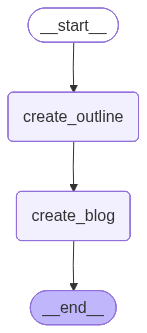

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())